# Section 0: Setup & Imports

In [1]:
# Standard Library
import os
import warnings
warnings.filterwarnings("ignore")

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing & Utilities
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

# Imbalanced Data
from imblearn.over_sampling import SMOTE

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve,
                             precision_recall_curve,
                             ConfusionMatrixDisplay)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Explainability
import shap

# Model Persistence
import joblib

# Global Configuration
SEED        = 42
TEST_SIZE   = 0.20
DATA_PATH   = "/Users/vishalhooda/Documents/Predictive-Maintenance-ML/data/ai4i2020.csv"
MODELS_DIR  = "../outputs/models/"
FIGURES_DIR = "../outputs/figures/"

# Create output directories if they don't exist
os.makedirs(MODELS_DIR, exist_ok = True)
os.makedirs(FIGURES_DIR, exist_ok = True)

# Reproducibility
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot Style
plt.rcParams.update({
    "figure.figsize"    : (10, 5),
    "figure.dpi"        : 120,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.titlesize"    : 14,
    "axes.labelsize"    : 12,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "legend.fontsize"   : 10,
    "font.family"       : "DejaVu Sans",
})

PALETTE = {
    "primary" : "#2563EB", # blue
    "danger"  : "#DC2626", # red
    "success" : "#16A34A", # green
    "warning" : "#D97706", # amber
    "neutral" : "#6B7280", # gray
    "rf"      : "#7C3AED", # violet -> Random Forest
    "xgb"     : "#EA580C", # orange -> XGBoost
    "nn"      : "#0891B2"  # cyan -> Neural Network
}

# Helper - Save Figure
def save_fig(filename: str, tight: bool = True) -> None:
    """Save the current matplotlib figure to the figures directory."""
    path = os.path.join(FIGURES_DIR, filename)
    if tight:
        plt.tight_layout()
    plt.savefig(path, bbox_inches = 'tight')
    print(f"Figure saved -> {path}")

# Helper - Print Section Banner
def section_banner(title: str) -> None:
    """Print a clearly visible section divider in notebook output."""
    bar = "=" * 60
    print(f"\n{bar}")
    print(f"  {title}")
    print(f"{bar}\n")

# Environment Verification
section_banner("Section 0 - Environment Verification")
libs = {
    "Numpy"            : np.__version__,
    "Pandas"           : pd.__version__,
    "Scikit-learn"     : __import__("sklearn").__version__,
    "XGBoost"          : __import__("xgboost").__version__,
    "Tensorflow"       : tf.__version__,
    "SHAP"             : shap.__version__,
    "imbalanced-learn" : __import__("imblearn").__version__
}

print(f"{'Library':<20} {'Version':>10}")
print("-" * 32)
for lib, ver in libs.items():
    print(f"{lib:<20} {ver:>10}")

print(f"\n  Random Seed : {SEED}")
print(f"  Test Size : {TEST_SIZE * 100:.0f}%")
print(f"  Data Path    : {DATA_PATH}")
print(f"  Models Dir   : {MODELS_DIR}")
print(f"  Figures Dir  : {FIGURES_DIR}")
print(f"\n  GPU Available: {bool(tf.config.list_physical_devices('GPU'))}")


  Section 0 - Environment Verification

Library                 Version
--------------------------------
Numpy                    1.23.5
Pandas                    2.1.4
Scikit-learn              1.2.2
XGBoost                   2.0.3
Tensorflow               2.12.0
SHAP                     0.47.2
imbalanced-learn         0.11.0

  Random Seed : 42
  Test Size : 20%
  Data Path    : /Users/vishalhooda/Documents/Predictive-Maintenance-ML/data/ai4i2020.csv
  Models Dir   : ../outputs/models/
  Figures Dir  : ../outputs/figures/

  GPU Available: False


# Section 1: Data Loading & Exploration

In [2]:
# Load Dataset
section_banner("Section 1 - Data Loading & Exploration")

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# First Look
print("\nFirst 5 Rows")
display(df.head())

print("\nColumn Info")
display(df.dtypes.rename("dtype").to_frame())

print("\nBasic Statistics")
display(df.describe().T.round(3))


  Section 1 - Data Loading & Exploration

Rows: 10,000
Columns: 14

First 5 Rows


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Column Info


,dtype
UDI,int64
Product ID,object
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64



Basic Statistics


,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.500,2886.896,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.005,2.000,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.006,1.484,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.776,179.284,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.987,9.969,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.951,63.654,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.034,0.181,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.005,0.068,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.012,0.107,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.010,0.097,0.0,0.00,0.0,0.00,1.0


In [3]:
# Missing Values
print("\nMissing Values")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing,
                           "Missing %" : missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]

if missing_df.empty:
    print("No missing values found.")
else:
    display(missing_df)


Missing Values
No missing values found.


In [4]:
# Drop Non-Feature Columns
# UDI = row index, Product ID = alphanumeric ID - neither carries
# predictive signal; remove them before any analysis
df.drop(columns = ['UDI', 'Product ID'], inplace = True)
print(f"\nDropped 'UDI' and 'Product ID'. Remaining Columns: {list(df.columns)}")


Dropped 'UDI' and 'Product ID'. Remaining Columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [5]:
# Rename Columns for Cleaner Access
df.rename(columns = {
    "Air temperature [K]"     : "air_temp",
    "Process temperature [K]" : "process_temp",
    "Rotational speed [rpm]"  : "rot_speed",
    "Torque [Nm]"             : "torque",
    "Tool wear [min]"         : "tool_wear",
    "Machine failure"         : "failure",
    "TWF"                     : "tool_wear_failure",
    "HDF"                     : "heat_dissipation_failure",
    "PWF"                     : "power_failure",
    "OSF"                     : "overstrain_failure",
    "RNF"                     : "random_failure",
    "Type"                    : "machine_type"
}, inplace = True)

print(f"\n Columns after rename: {list(df.columns)}")


 Columns after rename: ['machine_type', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'failure', 'tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']


Figure saved -> ../outputs/figures/1_target_distribution.png


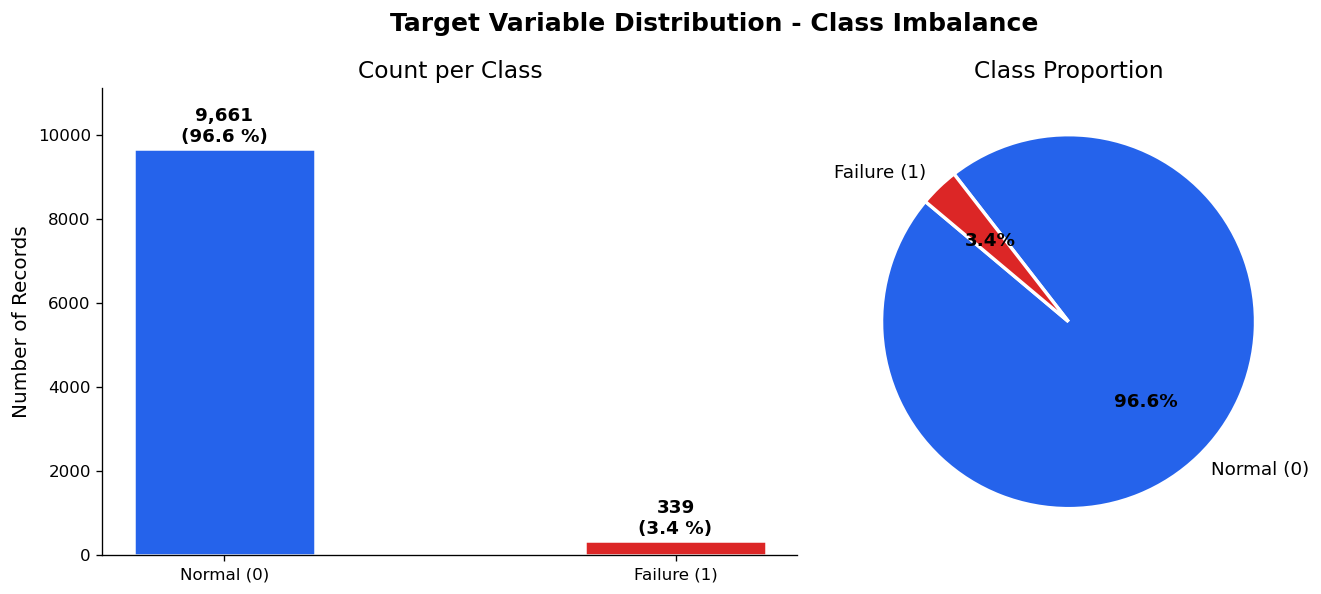


Imbalance Ration -> Normal: Failure = 9,661 : 339 (96.6% vs 3.4%)


In [6]:
# Target Distribution - Class Imbalance
counts = df['failure'].value_counts()
pct = df['failure'].value_counts(normalize = True) * 100
labels = ['Normal (0)', 'Failure (1)']
colors = [PALETTE['primary'], PALETTE['danger']]

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
fig.suptitle("Target Variable Distribution - Class Imbalance", fontsize = 15, fontweight = 'bold')

# Bar Chart
axes[0].bar(labels, counts.values, color = colors, width = 0.4, edgecolor = 'white', linewidth = 1.5)
for i, (cnt, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, cnt + 80, f"{cnt:,}\n({p:.1f} %)", ha = 'center', va = 'bottom', fontsize = 11, fontweight = 'bold')

axes[0].set_title('Count per Class')
axes[0].set_ylabel('Number of Records')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie Chart
wedges, texts, autotexts = axes[1].pie(counts.values, labels = labels, colors = colors, autopct = '%1.1f%%', startangle = 140, 
                                       wedgeprops = dict(edgecolor = 'white', linewidth = 2), textprops = dict(fontsize = 11))
for at in autotexts:
    at.set_fontweight('bold')

axes[1].set_title('Class Proportion')

plt.tight_layout()
save_fig('1_target_distribution.png')
plt.show()

print(f'\nImbalance Ration -> Normal: Failure = '
      f'{counts[0]:,} : {counts[1]:,} '
      f'({pct[0]:.1f}% vs {pct[1]:.1f}%)')

Figure saved -> ../outputs/figures/1_failure_type_breakdown.png


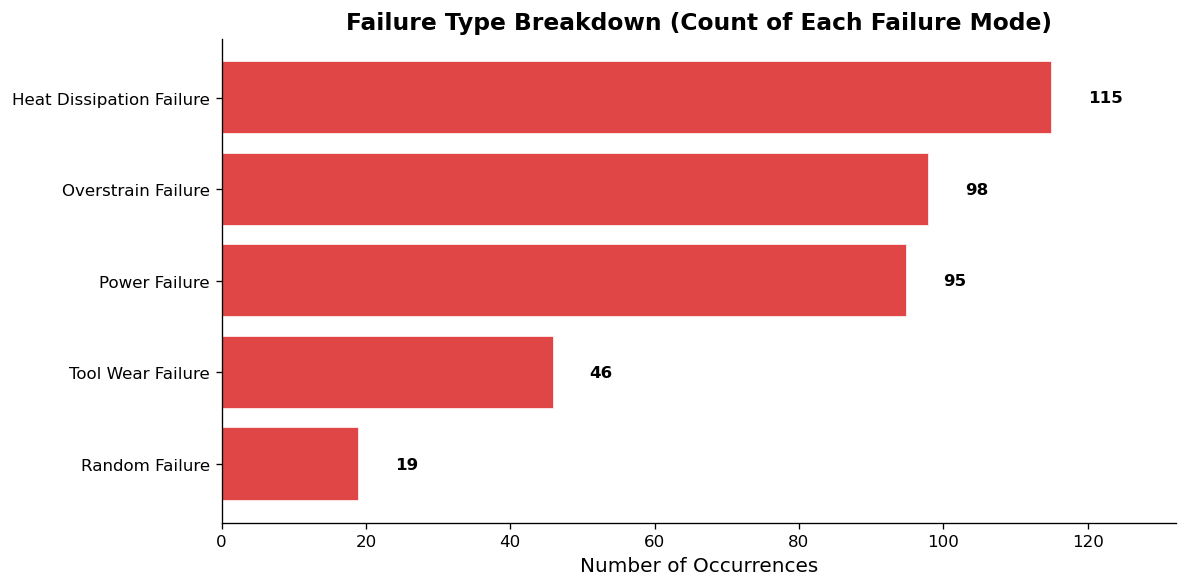

In [7]:
# Failure Type Breakdown
failure_cols = ['tool_wear_failure', 'heat_dissipation_failure', 'power_failure', 'overstrain_failure', 'random_failure']
failure_counts = df[failure_cols].sum().sort_values(ascending = True)

fig, ax = plt.subplots(figsize = (10, 5))
bars = ax.barh(failure_counts.index, failure_counts.values, color = PALETTE['danger'], edgecolor = 'white', linewidth = 1.2, alpha = 0.85)

for bar, val in zip(bars, failure_counts.values):
    ax.text(val + 5, bar.get_y() + bar.get_height() / 2, f'{val:,}', va = 'center', fontsize = 10, fontweight = 'bold')

ax.set_title('Failure Type Breakdown (Count of Each Failure Mode)', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('Number of Occurrences')
ax.set_xlim(0, failure_counts.max() * 1.15)
ax.set_yticklabels([c.replace("_", " ").title() for c in failure_counts.index])
save_fig("1_failure_type_breakdown.png")
plt.show()

Figure saved -> ../outputs/figures/1_feature_distributions.png


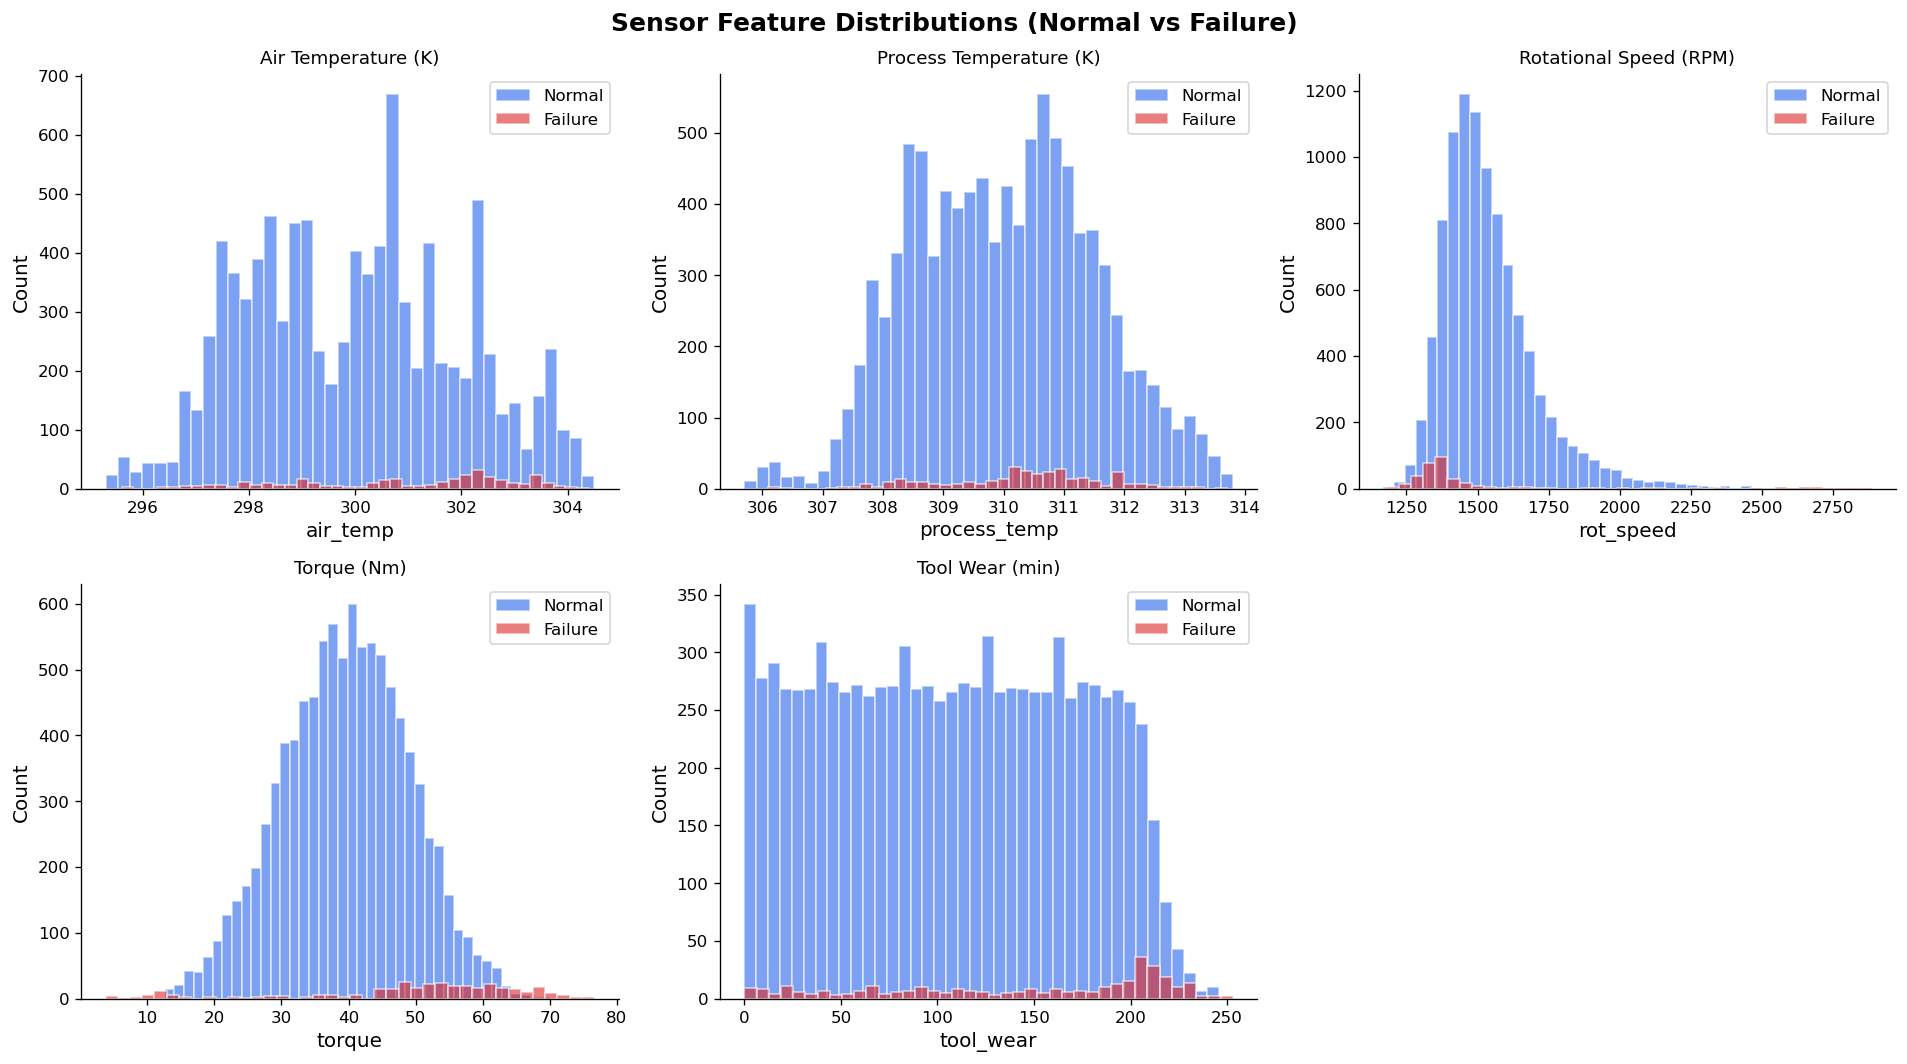

In [8]:
# Numerical Feature Distribution
num_features = ['air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear']
titles = ['Air Temperature (K)', 'Process Temperature (K)', 'Rotational Speed (RPM)', 'Torque (Nm)', 'Tool Wear (min)']

fig, axes = plt.subplots(2, 3, figsize = (16, 9))
fig.suptitle('Sensor Feature Distributions (Normal vs Failure)', fontsize = 15, fontweight = 'bold')
axes = axes.flatten()

for i, (feat, title) in enumerate(zip(num_features, titles)):
    for label, color, name in [(0, PALETTE['primary'], 'Normal'),
                               (1, PALETTE['danger'], 'Failure')]: axes[i].hist(df[df['failure'] == label][feat], bins = 40,
                                                                                alpha = 0.6, color = color, label = name, edgecolor = 'white')
        
    axes[i].set_title(title, fontsize = 11)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

axes[-1].axis('off')  # hide the unused 6th subplot
plt.tight_layout()
save_fig('1_feature_distributions.png')
plt.show()

Figure saved -> ../outputs/figures/1_correlation_heatmap.png


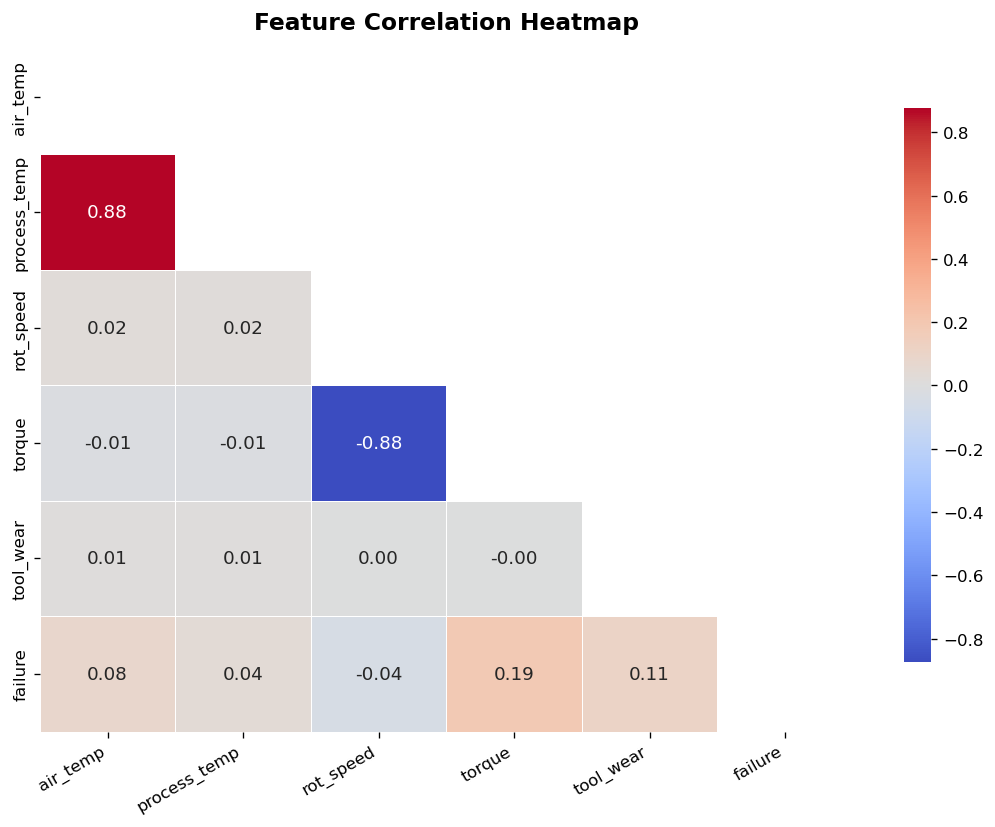

In [9]:
# Correlation Heatmap
corr_cols = num_features + ['failure']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize = (9, 7))
mask = np.triu(np.ones_like(corr, dtype = bool))  # show lower triangle only
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f', cmap = 'coolwarm', center = 0, linewidth = 0.5,
            annot_kws = {'size': 11}, ax = ax, cbar_kws = {'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 30, ha = 'right')
save_fig('1_correlation_heatmap.png')
plt.show()

Figure saved -> ../outputs/figures/1_machine_type_analysis.png


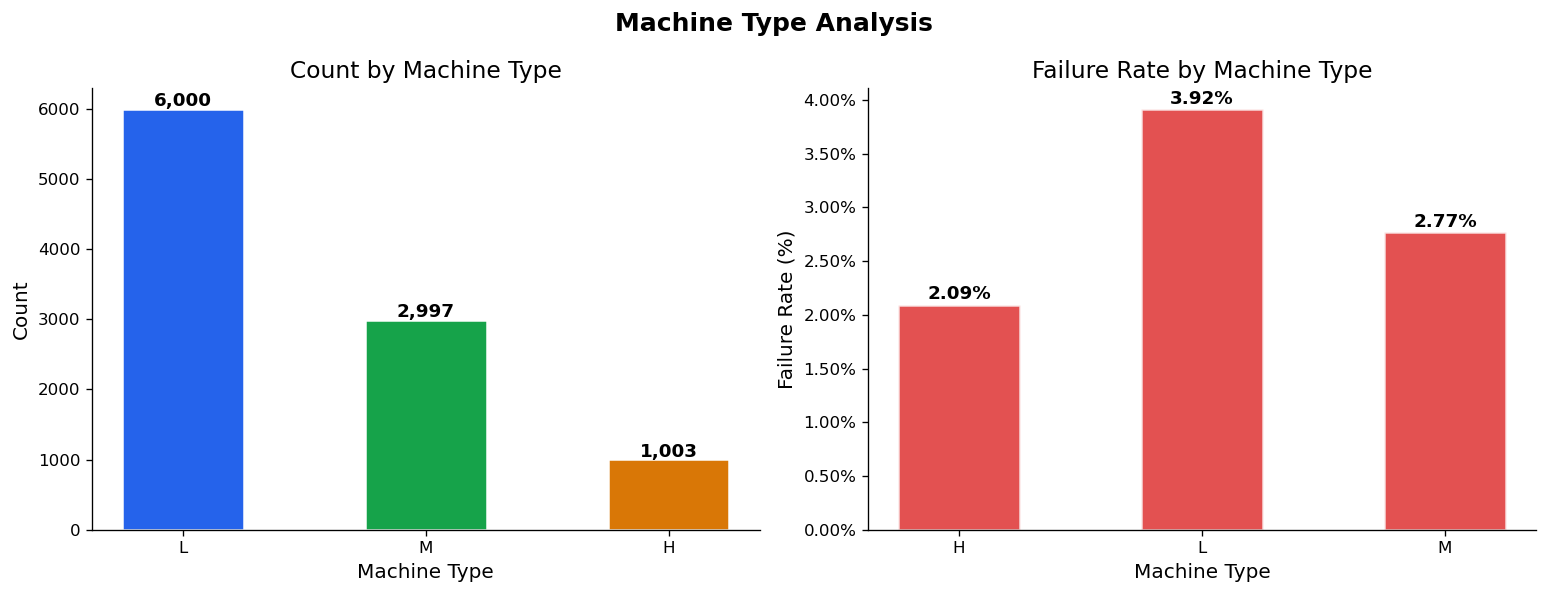

In [10]:
# Machine Tupe Distribution
type_counts = df['machine_type'].value_counts()
type_fail_rate = df.groupby('machine_type')['failure'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize = (13, 5))
fig.suptitle('Machine Type Analysis', fontsize = 15, fontweight = 'bold')

# Count per type
axes[0].bar(type_counts.index, type_counts.values, color = [PALETTE['primary'], PALETTE['success'], PALETTE['warning']],
            edgecolor = 'white', linewidth = 1.5, width = 0.5)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 40, f'{v:,}', ha = 'center', fontsize = 11, fontweight = 'bold')

axes[0].set_title('Count by Machine Type')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Machine Type')

# Failure rate per type
bars = axes[1].bar(type_fail_rate.index, type_fail_rate.values, color = PALETTE['danger'],
                   edgecolor = 'white', linewidth = 1.5, alpha = 0.8, width = 0.5)
for bar, val in zip(bars, type_fail_rate.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.05, f"{val:.2f}%",
                 ha = 'center', fontsize = 11, fontweight = 'bold')

axes[1].set_title('Failure Rate by Machine Type')
axes[1].set_ylabel('Failure Rate (%)')
axes[1].set_xlabel('Machine Type')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
save_fig('1_machine_type_analysis.png')
plt.show()

In [11]:
# Section Summary
section_banner("Section 1 - Summary")
print(f'Total Records      : {len(df):,}')
print(f'Features Available : {df.shape[1] - 1}')
print(f'Normal Samples     : {counts[0]:,} ({pct[0]:.1f}%)')
print(f'Failure Samples    : {counts[1]:,} ({pct[1]:.1f}%)')
print(f'Imbalance Ratio    : ~{round(counts[0]/counts[1])}:1')
print(f'Missing Values     : None')


  Section 1 - Summary

Total Records      : 10,000
Features Available : 11
Normal Samples     : 9,661 (96.6%)
Failure Samples    : 339 (3.4%)
Imbalance Ratio    : ~28:1
Missing Values     : None


# Section 2: Preprocessing & Feature Engineering

In [12]:
# Copy Working DataFrame
# Always work on a copy so the raw df is preserved for reference
df2 = df.copy()
print(f'Working copy created. Shape: {df2.shape}')

Working copy created. Shape: (10000, 12)


In [13]:
# Encode Categorical Feature - machine_type
print('\nEncoding machine_type')
print(f"Unique values before encoding: {df2['machine_type'].unique()}")

le = LabelEncoder()
df2['machine_type_enc'] = le.fit_transform(df2['machine_type'])

# Show the mapping clearly
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'Encoding map: {mapping}')
print(f"e.g. H -> {mapping['H']}  L -> {mapping['L']}  M -> {mapping['M']}")

# Save encoder for deployment use later
joblib.dump(le, os.path.join(MODELS_DIR, 'label_encoder.pkl'))
print("LabelEncoder saved -> outputs/models/label_encoder.pkl")


Encoding machine_type
Unique values before encoding: ['M' 'L' 'H']
Encoding map: {'H': 0, 'L': 1, 'M': 2}
e.g. H -> 0  L -> 1  M -> 2
LabelEncoder saved -> outputs/models/label_encoder.pkl


In [14]:
# Feature Engineering - Create 3 New Features

# Feature 1 - Power (Watts)
# Physics: Power = Torque * Angular Velocity (rad/s)
# rot_speed in RPM -> convert to rad/s: * (2π/60)
df2['power'] = df2['torque'] * (df2['rot_speed'] * 2 * np.pi / 60)

# Feature 2 - Temperature Differential (K)
# High temp diff between process and air can stress components
df2['temp_diff'] = df2['process_temp'] - df2['air_temp']

# Feature 3 - Tool Wear * Torque interaction
# High wear under high torque = compounding stress
df2['wear_torque'] = df2['tool_wear'] * df['torque']

print('power = torque * (rot_speed * 2π / 60)')
print('temp_diff = process_temp - air_temp')
print('wear_torque = tool_wear * torque')

# Verify new columns
print(f"\nNew Features Preview:")
display(df2[['power', 'temp_diff', 'wear_torque']].describe().T.round(3))

power = torque * (rot_speed * 2π / 60)
temp_diff = process_temp - air_temp
wear_torque = tool_wear * torque

New Features Preview:


,count,mean,std,min,25%,50%,75%,max
power,10000.0,6279.745,1067.418,1148.441,5561.184,6271.027,7003.003,10469.923
temp_diff,10000.0,10.001,1.001,7.600,9.300,9.800,11.000,12.100
wear_torque,10000.0,4314.665,2826.568,0.000,1963.650,4012.950,6279.000,16497.000


Figure saved -> ../outputs/figures/2_engineered_features.png


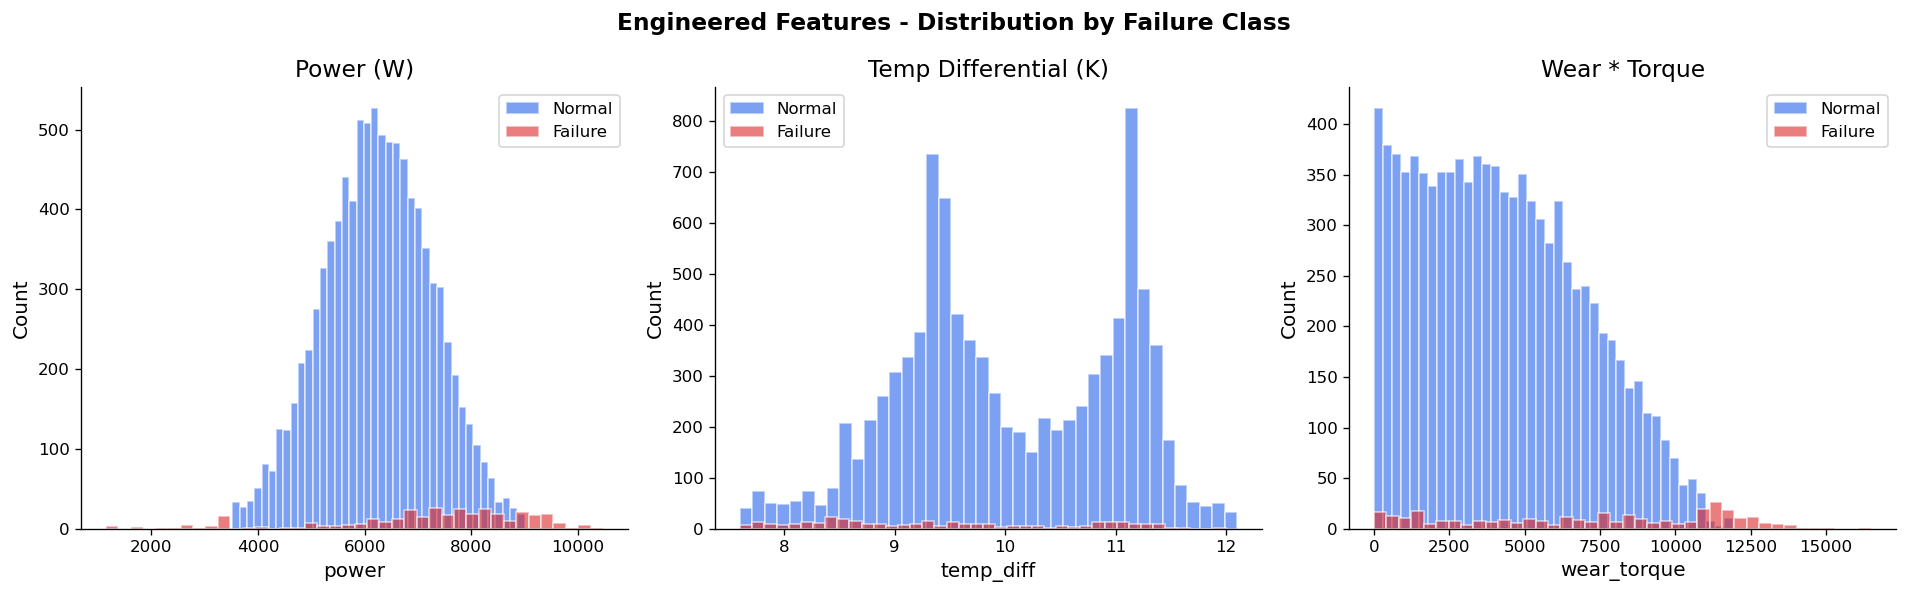

In [15]:
# Visualize Engineered Features vs Failure
eng_features = ['power', 'temp_diff', 'wear_torque']
eng_title = ['Power (W)', 'Temp Differential (K)', 'Wear * Torque']

fig, axes = plt.subplots(1, 3, figsize = (16, 5))
fig.suptitle('Engineered Features - Distribution by Failure Class', fontsize = 14, fontweight = 'bold')

for ax, feat, title in zip(axes, eng_features, eng_title):
    for label, color, name in [(0, PALETTE['primary'], 'Normal'), (1, PALETTE['danger'], 'Failure')]:
        ax.hist(df2[df2['failure'] == label][feat], bins = 40, alpha = 0.6, color = color, label = name, edgecolor = 'white')
        ax.set_title(title)
        ax.set_xlabel(feat)
        ax.set_ylabel('Count')
        ax.legend()

plt.tight_layout()
save_fig('2_engineered_features.png')
plt.show()

In [16]:
# Define Final Feature Set
print('Final Feature Set')

# Drop original machine_type string column and all sub_failure cols (sub_failure cols like tool_wear_failure are leakege - they directly 
# define the target and should NOT be model inputs)

FEATURE_COLS = ['machine_type_enc', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'power', 'temp_diff', 'wear_torque']
TARGET_COL = 'failure'

X = df2[FEATURE_COLS]
y = df2[TARGET_COL]

print(f"Features : {FEATURE_COLS}")
print(f"Target   : {TARGET_COL}")
print(f"X shape  : {X.shape}")
print(f"y shape  : {y.shape}")
print(f"Class balance -> 0: {(y == 0).sum():,} | 1: {(y == 1).sum():,}")

Final Feature Set
Features : ['machine_type_enc', 'air_temp', 'process_temp', 'rot_speed', 'torque', 'tool_wear', 'power', 'temp_diff', 'wear_torque']
Target   : failure
X shape  : (10000, 9)
y shape  : (10000,)
Class balance -> 0: 9,661 | 1: 339


In [17]:
# Train / Test Split
print('Train / Test Split')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = TEST_SIZE, random_state = SEED, 
                                                    stratify = y) # preserves class ratio in both splits

print(f"Train set: {X_train.shape[0]:,} rows " 
      f"(failures: {y_train.sum():,} = {y_train.mean() * 100:.1f}%)")
print(f"Test set: {X_test.shape[1]:,} rows " 
      f"(failures: {y_test.sum():,} = {y_test.mean() * 100:.1f}%)")

print("Stratified split - failure % preserved in both sets")

Train / Test Split
Train set: 8,000 rows (failures: 271 = 3.4%)
Test set: 9 rows (failures: 68 = 3.4%)
Stratified split - failure % preserved in both sets


In [18]:
# Feature Scaling (for Neural Networks)
print('Feature Scaling')

scaler = StandardScaler()

# Important: Fit ONLY on training data - never on test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# Convert back to DataFrame to retain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns = FEATURE_COLS)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = FEATURE_COLS)

print("Scaler fitted on training data only")
print("Transform applied to both train & test sets")
print(f"\nPre-scale mean (rot_speed): {X_train['rot_speed'].mean():.2f}")
print(f"Post-scale mean (rot_speed): {X_train_scaled['rot_speed'].mean():.4f}")

# Save scaler for deployment
joblib.dump(scaler, os.path.join(MODELS_DIR, "standard_scaler.pkl"))
print("\nStandardScaler saved -> outputs/models/standard_scaler.pkl")

Feature Scaling
Scaler fitted on training data only
Transform applied to both train & test sets

Pre-scale mean (rot_speed): 1539.36
Post-scale mean (rot_speed): 0.0000

StandardScaler saved -> outputs/models/standard_scaler.pkl


Figure saved -> ../outputs/figures/2_scaling_before_after.png


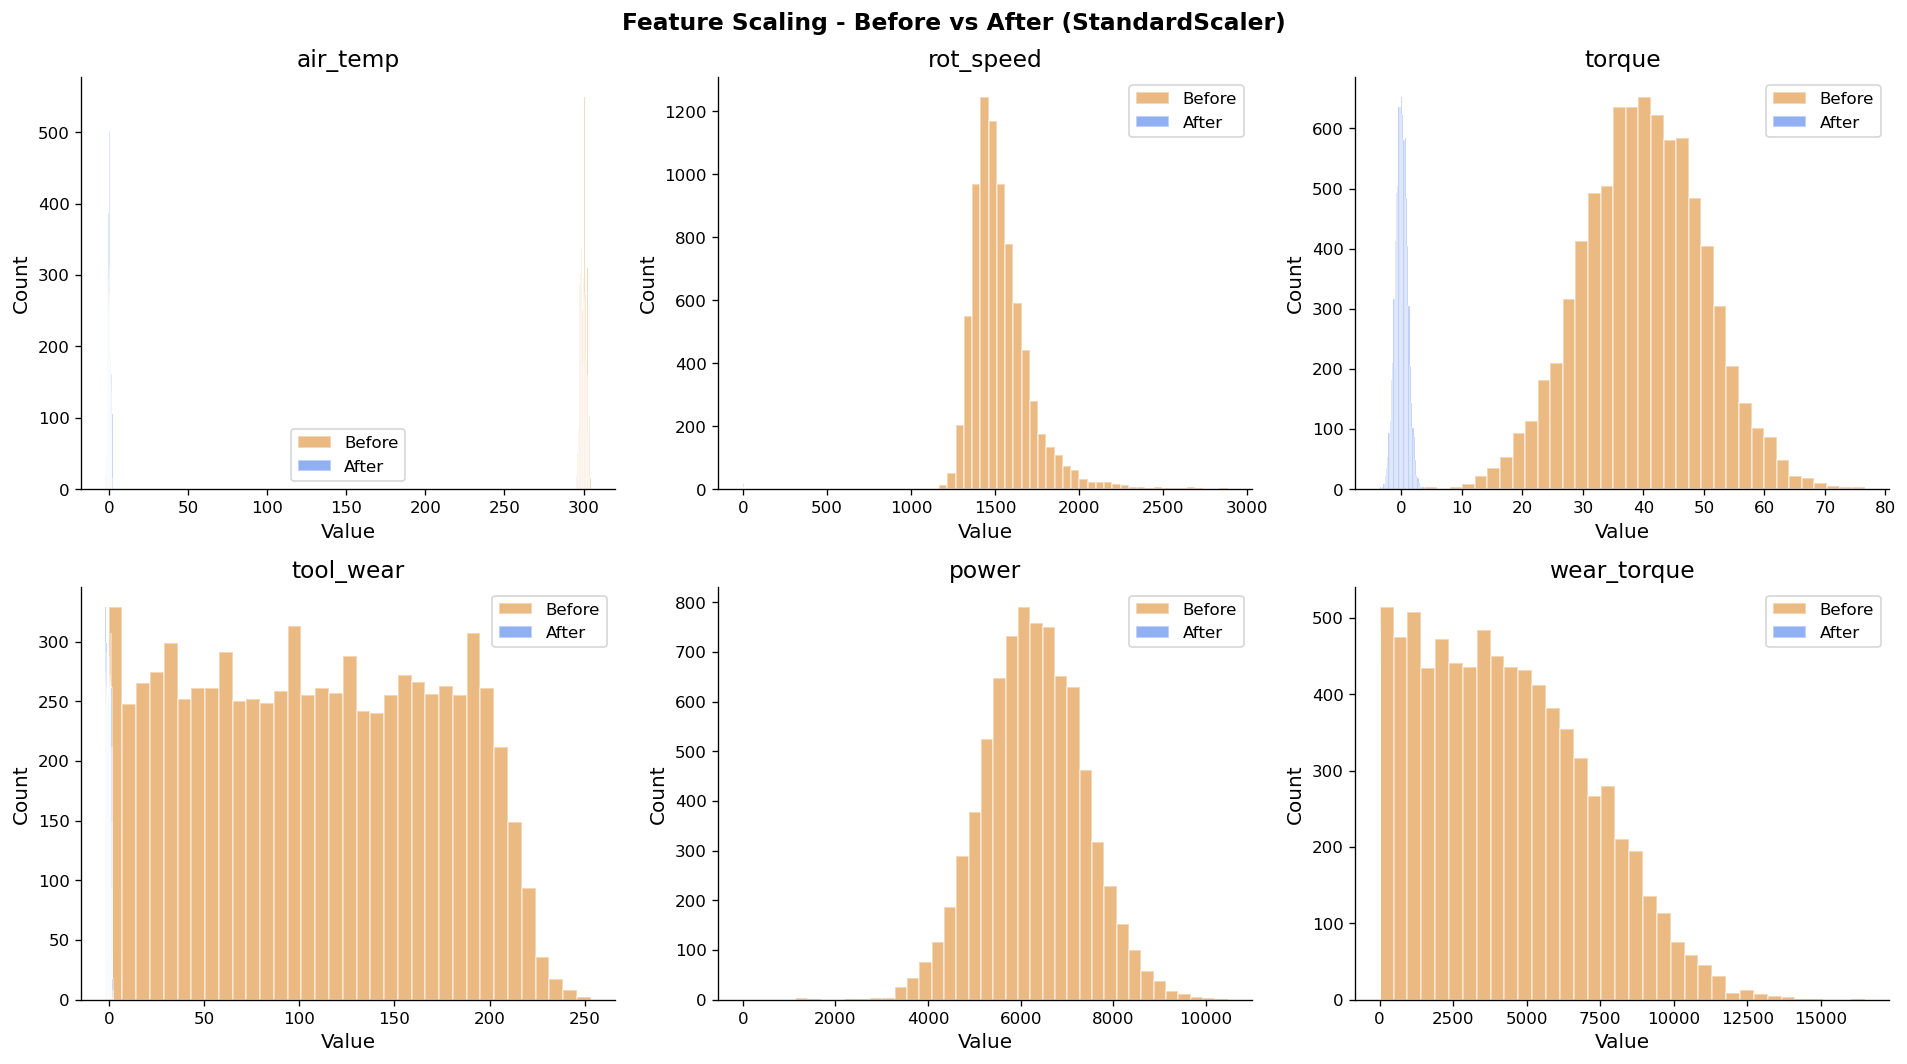

In [19]:
# Before vs After Scaling - Visualization
fig, axes = plt.subplots(2, 3, figsize = (16, 9))
fig.suptitle('Feature Scaling - Before vs After (StandardScaler)', 
             fontsize = 14, fontweight = 'bold')
axes = axes.flatten()

sample_feats = ['air_temp', 'rot_speed', 'torque', 'tool_wear', 'power', 'wear_torque']

for i, feat in enumerate(sample_feats):
    axes[i].hist(X_train[feat], bins = 35, alpha = 0.5, color = PALETTE['warning'],
                 label = 'Before', edgecolor = 'white')
    axes[i].hist(X_train_scaled[feat], bins = 35, alpha = 0.5, color = PALETTE['primary'],
                label = 'After', edgecolor = 'white')
    axes[i].set_title(feat)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
save_fig('2_scaling_before_after.png')
plt.show()

In [20]:
# Compute Class Weights (for tree models)
print('Class Weights')

classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes = classes, y = y_train)
CLASS_WEIGHT = dict(zip(classes, weights))

print(f"Class weights : {CLASS_WEIGHT}")
print(f"-> Failure class weighted {CLASS_WEIGHT[1]:.1f}* higher than Normal")
print("(Used in Random Forest & Neural Network training)")

Class Weights
Class weights : {0: 0.51753137533963, 1: 14.760147601476016}
-> Failure class weighted 14.8* higher than Normal
(Used in Random Forest & Neural Network training)


In [21]:
# Section Summary
section_banner('Section 2 - Summary')

print('Completed Steps:')
print('machine_type label-encoded (H = 0, L = 1, M = 2)')
print('3 new features engineered (power, temp_diff, wear_torque)')
print(f'Train / Test split ({int((1 - TEST_SIZE) * 100)} / {int(TEST_SIZE * 100)}, stratified)')
print('StandardScaler fitted (train only, test transformed)')
print(f"Class weights computed {CLASS_WEIGHT}")
print(f"\nDatasets ready:")
print(f"X_train / y_train {X_train.shape} (tree models - unscaled)")
print(f"X_train_scaled / y_train -> {X_train_scaled.shape} (neural network - scaled)")
print(f"X_test / y_test -> {X_test.shape} (evaluation)")


  Section 2 - Summary

Completed Steps:
machine_type label-encoded (H = 0, L = 1, M = 2)
3 new features engineered (power, temp_diff, wear_torque)
Train / Test split (80 / 20, stratified)
StandardScaler fitted (train only, test transformed)
Class weights computed {0: 0.51753137533963, 1: 14.760147601476016}

Datasets ready:
X_train / y_train (8000, 9) (tree models - unscaled)
X_train_scaled / y_train -> (8000, 9) (neural network - scaled)
X_test / y_test -> (2000, 9) (evaluation)


# Section 3 - Handling Imbalanced Data (SMOTE)

In [22]:
# Recap - Original Class Distribution
print('Original Training Set Distributin')

orig_counts = y_train.value_counts().sort_index()
orig_pct = y_train.value_counts(normalize = True).sort_index() * 100

print(f"Normal (0): {orig_counts[0]:,} ({orig_pct[0]:.1f}%)")
print(f"Failure (1): {orig_counts[1]:,} ({orig_pct[1]:.1f}%)")
print(f"Imbalance ratio: {orig_counts[0] // orig_counts[1]}:.1")

Original Training Set Distributin
Normal (0): 7,729 (96.6%)
Failure (1): 271 (3.4%)
Imbalance ratio: 28:.1


In [23]:
# Apply SMOTE on training set only
print('Applying SMOTE')

# CRITICAL RULE: SMOTE is applied only to the training set.
# Never apply to the test set - test set must reflect real-world distribution to give honest evaluation metrics.

smote = SMOTE(sampling_strategy = 0.5, # after SMOTE: failure = 50% of normal count
              random_state = SEED, 
              k_neighbors = 5, # default; uses 5 nearest neighbours
             )

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Also apply SMOTE to scaled training set (for Neural Network)
X_train_scaled_sm, y_train_scaled_sm = smote.fit_resample(X_train_scaled, y_train)

# Post-SMOTE counts
sm_counts = pd.Series(y_train_sm).value_counts().sort_index()
sm_pct = pd.Series(y_train_sm).value_counts(normalize = True).sort_index() * 100

print(f"Normal (0) : {sm_counts[0]:,} ({sm_pct[0]:.1f}%)")
print(f"Failure (1) : {sm_counts[1]:,} ({sm_pct[1]:.1f}%)")
print(f"New Imbalance ratio : {sm_counts[0] // sm_counts[1]}:1")
print(f"\nSynthetic failure samples created : "
      f"{sm_counts[1] - orig_counts[1]:,}")
print(f"Total training samples (after SMOTE): {len(X_train_sm):,}")

Applying SMOTE
Normal (0) : 7,729 (66.7%)
Failure (1) : 3,864 (33.3%)
New Imbalance ratio : 2:1

Synthetic failure samples created : 3,593
Total training samples (after SMOTE): 11,593


Figure saved -> ../outputs/figures/3_smote_before_after.png


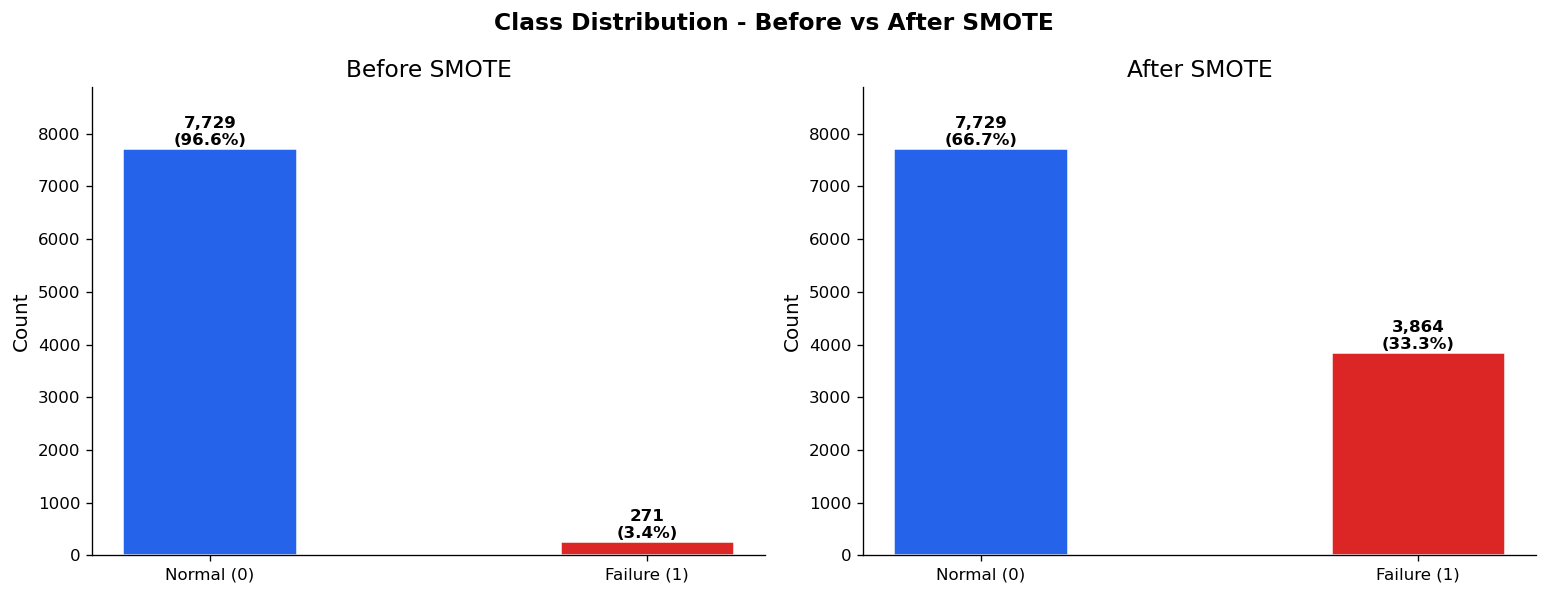

In [24]:
# Before vs After SMOTE - Bar Comparison
fig, axes = plt.subplots(1, 2, figsize = (13, 5))
fig.suptitle("Class Distribution - Before vs After SMOTE", fontsize = 14, fontweight = 'bold')

labels = ['Normal (0)', 'Failure (1)']
colors = [PALETTE['primary'], PALETTE['danger']]
x = np.arange(len(labels))
width = 0.35

# Before 
b1 = axes[0].bar(x, orig_counts.values, color = colors, edgecolor = 'white', linewidth = 1.5, width = 0.4)
for bar, cnt, pct in zip(b1, orig_counts.values, orig_pct.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50, 
                 f"{cnt:,}\n({pct:.1f}%)", ha = 'center', fontsize = 10, fontweight = 'bold')
    axes[0].set_title('Before SMOTE')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('Count')
    axes[0].set_ylim(0, orig_counts.max() * 1.15)

# After
b2 = axes[1].bar(x, sm_counts.values, color = colors, edgecolor = 'white', 
                 linewidth = 1.5, width = 0.4)
for bar, cnt, pct in zip(b2, sm_counts.values, sm_pct.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
                 f"{cnt:,}\n({pct:.1f}%)", ha = 'center', fontsize = 10, fontweight = 'bold')
    axes[1].set_title('After SMOTE')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('Count')
    axes[1].set_ylim(0, sm_counts.max() * 1.15)

plt.tight_layout()
save_fig('3_smote_before_after.png')
plt.show()

Visualising Real vs Synthetic Samples (PCA)
Figure saved -> ../outputs/figures/3_pca_real_vs_synthetic.png


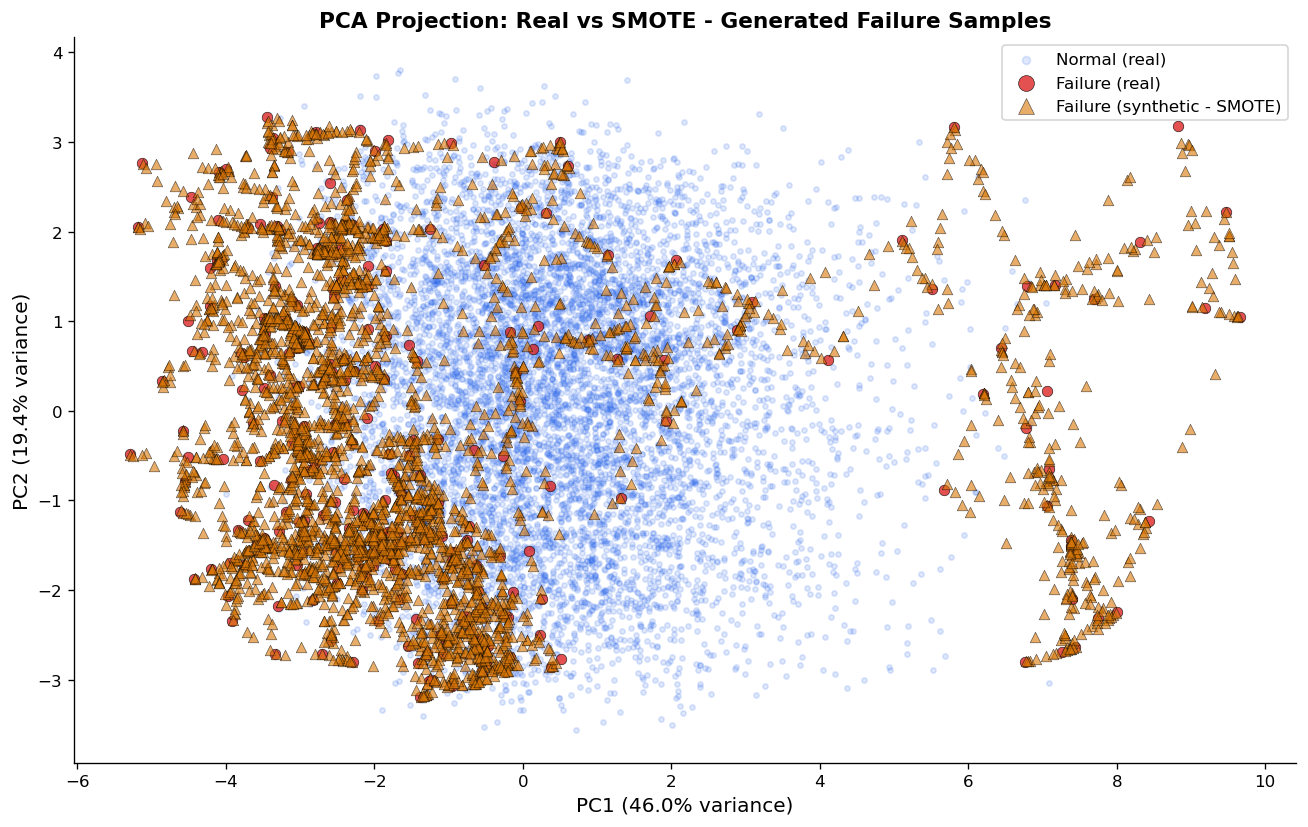

PCA explained variance - PC1: 46.0% PC2: 19.4%


In [25]:
# SMOTE Mechanism Visualisation
# Using PCA to reduce to 2D and show real vs synthetic samples
print('Visualising Real vs Synthetic Samples (PCA)')

from sklearn.decomposition import PCA

# Use scaled data for PCA
pca = PCA(n_components = 2, random_state = SEED)

# Combine original and SMOTE data to project into same 2D space
X_pca_sm = pca.fit_transform(X_train_scaled_sm)
X_pca_orig = pca.transform(X_train_scaled)

# Identify which SMOTE points are synthetic (the extra rows added beyond the original training size)
n_orig_failures = orig_counts[1]

# Indices in SMOTE output: real failures are first n_orig_failures rows among all failure rows
failure_mask_sm = (pd.Series(y_train_sm) == 1).values
failure_idx_sm = np.where(failure_mask_sm)[0]

real_fail_idx = failure_idx_sm[:n_orig_failures]
synthetic_fail_idx = failure_idx_sm[n_orig_failures:]

fig, ax = plt.subplots(figsize = (11, 7))
normal_mask = (pd.Series(y_train_sm) == 0).values
ax.scatter(X_pca_sm[normal_mask, 0], X_pca_sm[normal_mask, 1], c = PALETTE['primary'],
           alpha = 0.15, s = 10, label = 'Normal (real)')

# Real Failures
ax.scatter(X_pca_sm[real_fail_idx, 0], X_pca_sm[real_fail_idx, 1], c = PALETTE['danger'],
           alpha = 0.8, s = 40, edgecolor = 'black', linewidths = 0.4, label = 'Failure (real)')

# Synthetic failures
ax.scatter(X_pca_sm[synthetic_fail_idx, 0], X_pca_sm[synthetic_fail_idx, 1], c = PALETTE['warning'], alpha = 0.6,
           s = 40, edgecolor = 'black', linewidths = 0.4, marker = '^', label = 'Failure (synthetic - SMOTE)')

ax.set_title('PCA Projection: Real vs SMOTE - Generated Failure Samples', 
             fontsize = 13, fontweight = 'bold')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
ax.legend(markerscale = 1.5)

save_fig('3_pca_real_vs_synthetic.png')
plt.show()

print(f"PCA explained variance - PC1: " 
      f"{pca.explained_variance_ratio_[0] * 100:.1f}% "
f"PC2: {pca.explained_variance_ratio_[1] * 100:.1f}%")


Feature Distribution Shift After SMOTE
Figure saved -> ../outputs/figures/3_distribution_shift_check.png


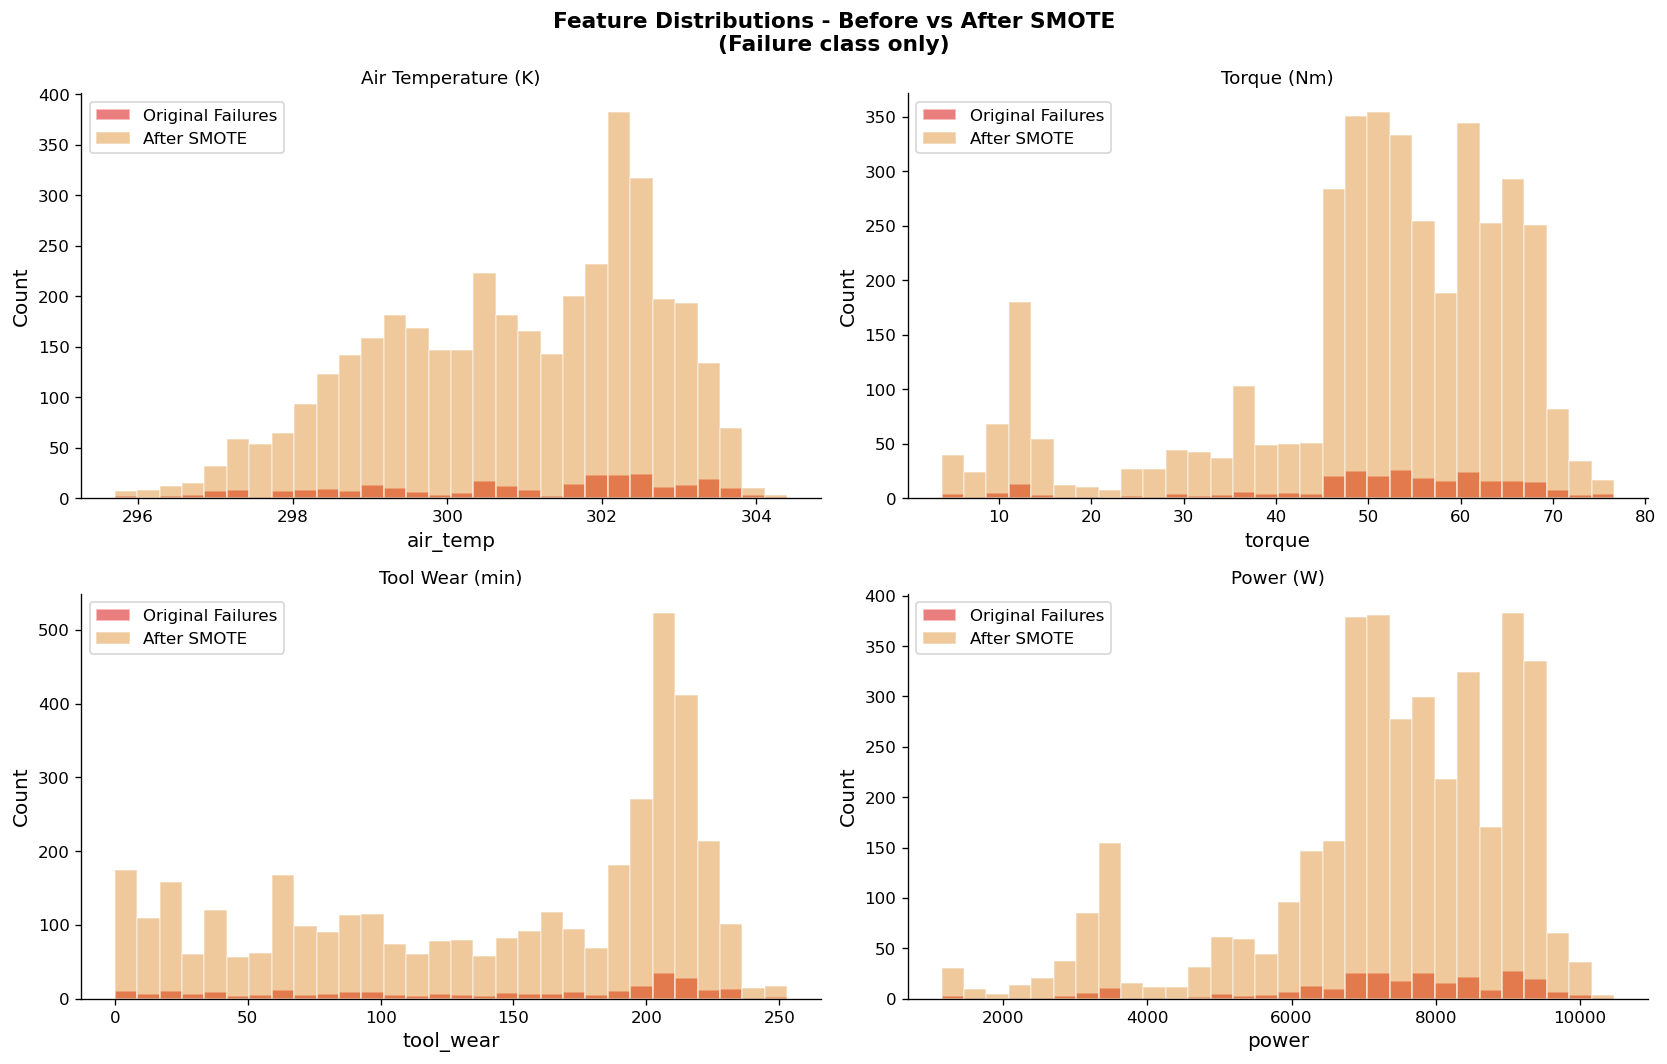

Distributions consistent - SMOTE preserved feature space


In [26]:
# Feature Distribution Shift Check
# Verify SMOTE didn't distort feature distributions

print("\nFeature Distribution Shift After SMOTE")

check_feats = ['air_temp', 'torque', 'tool_wear', 'power']
check_titles = ['Air Temperature (K)', 'Torque (Nm)', 'Tool Wear (min)', 'Power (W)']

fig, axes = plt.subplots(2, 2, figsize = (14, 9))
fig.suptitle('Feature Distributions - Before vs After SMOTE\n(Failure class only)', 
              fontsize = 13, fontweight = 'bold')
axes = axes.flatten()

for ax, feat, title in zip(axes, check_feats, check_titles):
    # Original failure samples
    orig_fail_vals = X_train[y_train == 1][feat]
    # SMOTE failure samples (all features rows in resampled set)
    sm_fail_vals = X_train_sm[y_train_sm == 1][feat]

    ax.hist(orig_fail_vals, bins = 30, alpha = 0.6, color = PALETTE['danger'],
            label = 'Original Failures', edgecolor = 'white')
    ax.hist(sm_fail_vals, bins = 30, alpha = 0.4, color = PALETTE['warning'], 
            label = 'After SMOTE', edgecolor = 'white')
    ax.set_title(title, fontsize = 11)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
save_fig('3_distribution_shift_check.png')
plt.show()

print("Distributions consistent - SMOTE preserved feature space")

In [27]:
# Strategies Summary Table
# Show all 3 imbalance-handling strategies used in this project

print('Imbalance Handling Strategies Summary\n')

strategies = {
    'Strategy' : ['SMOTE', "class_weight = 'balanced'", 'scale_pos_weight'],
    'Applied To' : ['Neural Network', 'Random Forest', 'XGBoost'],
    'How It Works' : ['Generates synthetic minority samples by interpolating between neighbours',
                      'Penalises misclassification of minority class during tree splits',
                      "Ratio of negative/positive samples; weight loss for minority class",
    ],
    'When Applied' : ['Before training', 'During training', 'During training'],
}

strat_df = pd.DataFrame(strategies)
display(strat_df)

Imbalance Handling Strategies Summary



,Strategy,Applied To,How It Works,When Applied
0,SMOTE,Neural Network,Generates synthetic minority samples by interp...,Before training
1,class_weight = 'balanced',Random Forest,Penalises misclassification of minority class ...,During training
2,scale_pos_weight,XGBoost,Ratio of negative/positive samples; weight los...,During training


In [28]:
# Datasets Available For Modeling

print('\nDatasets Ready for Modeling\n')

datasets = {
    "Variable" : [
        'X_train / y_train',
        'X_train_sm / y_train_sm',
        'X_train_scaled / y_train',
        'X_train_scaled_sm / y_train_scaled_sm',
        'X_test / y_test',
        'X_test_scaled / y_test',
    ],
    'Used For' : [
        'Random Forest (unscaled, class weight)',
        'XGBoost (unscaled, scale_pos_weight)',
        'Reference',
        'Neural Network (scaled + SMOTE)',
        'Evaluation - all tree models',
        'Evaluation - Neural Netwrork',
    ],
    'Shape' : [
        str(X_train.shape),
        str(X_train_sm.shape),
        str(X_train_scaled.shape),
        str(X_train_scaled_sm.shape),
        str(X_test.shape),
        str(X_test_scaled.shape),
    ],
}

ds_df = pd.DataFrame(datasets)
display(ds_df)


Datasets Ready for Modeling



,Variable,Used For,Shape
0,X_train / y_train,"Random Forest (unscaled, class weight)","(8000, 9)"
1,X_train_sm / y_train_sm,"XGBoost (unscaled, scale_pos_weight)","(11593, 9)"
2,X_train_scaled / y_train,Reference,"(8000, 9)"
3,X_train_scaled_sm / y_train_scaled_sm,Neural Network (scaled + SMOTE),"(11593, 9)"
4,X_test / y_test,Evaluation - all tree models,"(2000, 9)"
5,X_test_scaled / y_test,Evaluation - Neural Netwrork,"(2000, 9)"


In [29]:
# Section Summary
section_banner('Section 3 - Summary')

print(f"Original failure samples : {orig_counts[1]:,}")
print(f"Synthetic samples created : {sm_counts[1] - orig_counts[1]:,}")
print(f"Total failure samples now : {sm_counts[1]:,}")
print(f"New train set size : {len(X_train_sm):,}")
print(f"Test set unchanged : {len(X_test):,}")
print()
print('3 imbalance strategies prepared:')
print('SMOTE -> Neural Network training set')
print('class_weight -> Random Forest (Section 5)')
print('scale_pos_weight -> XGBoost (Section 6)')
print()


  Section 3 - Summary

Original failure samples : 271
Synthetic samples created : 3,593
Total failure samples now : 3,864
New train set size : 11,593
Test set unchanged : 2,000

3 imbalance strategies prepared:
SMOTE -> Neural Network training set
class_weight -> Random Forest (Section 5)
scale_pos_weight -> XGBoost (Section 6)



# Section 4 - Model 1: Random Forest

In [30]:
# Quick  sanity check before investing in hyperparameter search
print('Baseline Random Forest')

rf_base = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',  # handles imbalance without SMOTE
    random_state = SEED,
    n_jobs = -1,  # use all CPU cores
)

rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

print(f"Baseline Accuracy: {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Baseline F1-Score: {f1_score(y_test, y_pred_base):.4f}")
print(f"Baseline ROC-AUC: {roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1]):.4f}")

Baseline Random Forest
Baseline Accuracy: 0.9900
Baseline F1-Score: 0.8361
Baseline ROC-AUC: 0.9750


In [31]:
# Hyperparameter Tuning - RandomizedSerachCV
print('Hyperparameter Tuning (RandomSearchCV)')
print('Searching best parameters... (this may take 1-2 min)\n')

param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 20, 30, 40],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5],
    'bootstrap'         : [True, False]
}

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = SEED)

rf_search = RandomizedSearchCV(
    estimator = RandomForestClassifier(
        class_weight = 'balanced', random_state = SEED, n_jobs = -1),
    param_distributions = param_dist,
    n_iter = 30,  # test 30 random combinations
    scoring = 'f1',  # optimise for F1 (best for imbalanced)
    cv = cv,
    verbose = 1,
    random_state = SEED,
    n_jobs = -1,
)

rf_search.fit(X_train, y_train)

print(f"\nBest Parameters:")
for k, v in rf_search.best_params_.items():
    print(f"{k:<22}: {v}")
print(f"\n Best CV F1-Score : {rf_search.best_score_:.4f}")

Hyperparameter Tuning (RandomSearchCV)
Searching best parameters... (this may take 1-2 min)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters:
n_estimators          : 100
min_samples_split     : 5
min_samples_leaf      : 1
max_features          : 0.5
max_depth             : None
bootstrap             : False

 Best CV F1-Score : 0.8759


In [32]:
# Best Model - Train & Predict
print('Training Best Model')

rf_model = rf_search.best_estimator_
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print('Best model trained on full training set')

Training Best Model
Best model trained on full training set


In [33]:
# Evaluation Metrics
print('Evaluation Metrics')

rf_metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred_rf),
    'Precision' : precision_score(y_test, y_pred_rf),
    'Recall' : recall_score(y_test, y_pred_rf),
    'F1-Score' : f1_score(y_test, y_pred_rf),
    'ROC-AUC' : roc_auc_score(y_test, y_pred_rf)
}

print(f"{'Metrics':<14}  {'Score':>8}")
print(f"{'-------':<14}  {'-----':>8}")
for metric, score in rf_metrics.items():
    print(f"{metric:<14}  {score:>8.4f}")

print(f"\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names = ['Normal', 'Failure']))

Evaluation Metrics
Metrics            Score
-------            -----
Accuracy          0.9905
Precision         0.9298
Recall            0.7794
F1-Score          0.8480
ROC-AUC           0.8887

Classification Report:

              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      1932
     Failure       0.93      0.78      0.85        68

    accuracy                           0.99      2000
   macro avg       0.96      0.89      0.92      2000
weighted avg       0.99      0.99      0.99      2000



Figure saved -> ../outputs/figures/4_rf_confusion_matrix.png


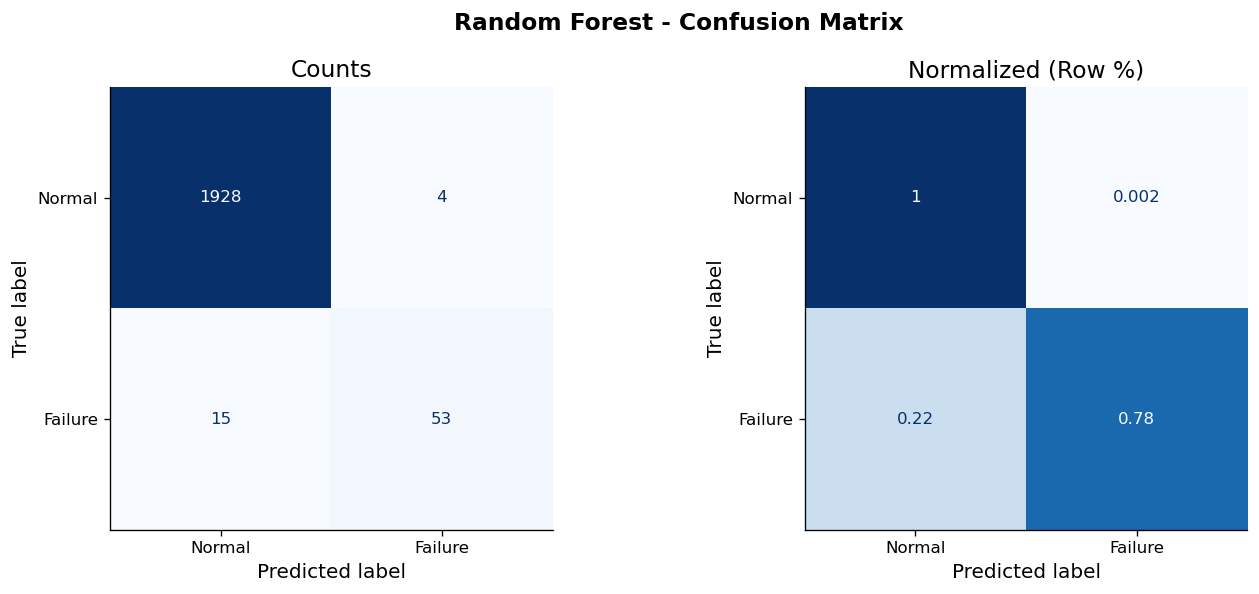


TP (Failures caught)  :   53
TN (Normal correct)    : 1928
FP (False alarms)      :    4
FN (Missed failures)   :   15 <- most costly in production


In [34]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

fig, axes = plt.subplots(1, 2, figsize = (14, 5))
fig.suptitle('Random Forest - Confusion Matrix', fontsize = 14, fontweight = 'bold')

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix = cm_rf, display_labels = ['Normal', 'Failure'])
disp.plot(ax = axes[0], colorbar = False, cmap = 'Blues')
axes[0].set_title('Counts')

# Normalized (%)
cm_norm = cm_rf.astype(float) / cm_rf.sum(axis = 1)[:, np.newaxis]
disp_norm = ConfusionMatrixDisplay(confusion_matrix = cm_norm.round(3), display_labels = ['Normal', 'Failure'])
disp_norm.plot(ax = axes[1], colorbar = False, cmap = 'Blues')
axes[1].set_title('Normalized (Row %)')

plt.tight_layout()
save_fig('4_rf_confusion_matrix.png')
plt.show()

print(f"\nTP (Failures caught)  : {tp:>4}")
print(f"TN (Normal correct)    : {tn:>4}")
print(f"FP (False alarms)      : {fp:>4}")
print(f"FN (Missed failures)   : {fn:>4} <- most costly in production")

Figure saved -> ../outputs/figures/4_rf_roc_curve.png


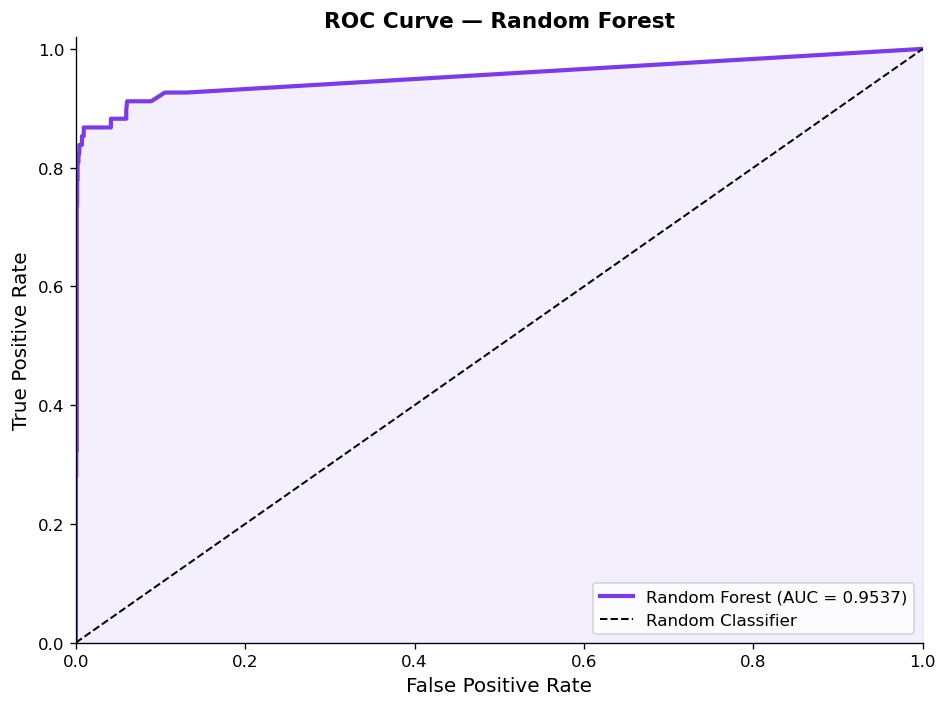

In [39]:
# ROC Curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf, tpr_rf, color=PALETTE["rf"], lw=2.5,
        label=f"Random Forest (AUC = {auc_rf:.4f})")
ax.plot([0, 1], [0, 1], "k--", lw=1.2, label="Random Classifier")
ax.fill_between(fpr_rf, tpr_rf, alpha=0.08, color=PALETTE["rf"])
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Random Forest", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
save_fig("4_rf_roc_curve.png")
plt.show()

Figure saved -> ../outputs/figures/4_rf_pr_curve.png


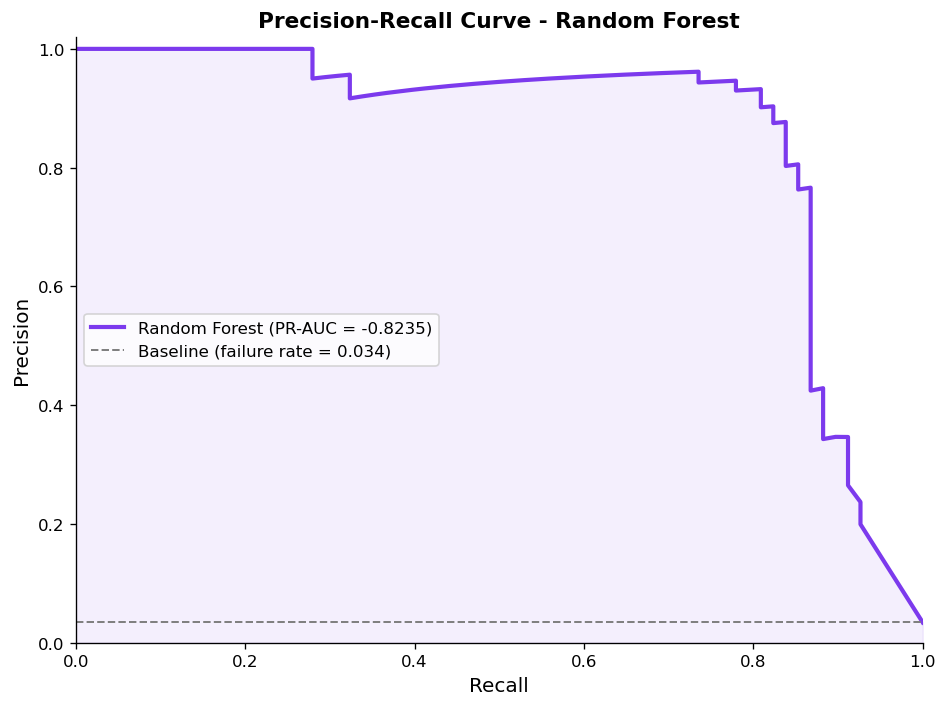

In [40]:
# Precision-Recall Curve
# More informative than ROC for imbalanced datasets
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_proba_rf)
pr_auc_rf = np.trapz(rec_rf[::-1], prec_rf[::-1])  # area under PR curve

fig, ax = plt.subplots(figsize = (8, 6))
ax.plot(rec_rf, prec_rf, color = PALETTE['rf'], lw = 2.5, label = f"Random Forest (PR-AUC = {pr_auc_rf:.4f})")
ax.axhline(y = y_test.mean(), color = 'gray', linestyle = '--', lw = 1.2, 
           label = f"Baseline (failure rate = {y_test.mean():.3f})")
ax.fill_between(rec_rf, prec_rf, alpha = 0.08, color = PALETTE['rf'])
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve - Random Forest', fontsize = 13, fontweight = 'bold')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
save_fig('4_rf_pr_curve.png')
plt.show()


Threshold Optimisation
Figure saved -> ../outputs/figures/4_rf_threshold_optimisation.png


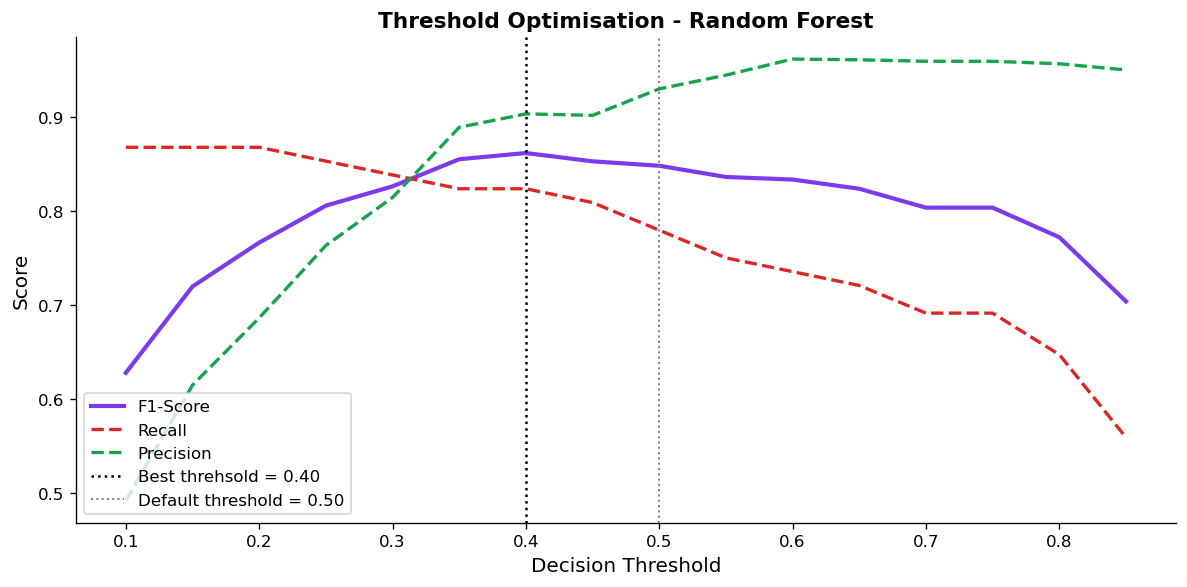

Default threshold (0.50) F1: 0.8480
Optimal theshold (0.40)  F1: 0.8615


In [44]:
# Threshold Optimisation
# Default threshold is 0.5 - but for imbalanced data, a lower threshold often improves Recall (catching more failures)
print('\nThreshold Optimisation')

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores_t = []
rec_scores_t = []
pre_scores_t = []

for t in thresholds: 
    y_pred_t = (y_proba_rf >= t).astype(int)
    f1_scores_t.append(f1_score(y_test, y_pred_t, zero_division = 0))
    rec_scores_t.append(recall_score(y_test, y_pred_t, zero_division = 0))
    pre_scores_t.append(precision_score(y_test, y_pred_t, zero_division = 0))

best_t = thresholds[np.argmax(f1_scores_t)]
best_f1_t = max(f1_scores_t)

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(thresholds, f1_scores_t, color = PALETTE['rf'], lw = 2.5, label = 'F1-Score')
ax.plot(thresholds, rec_scores_t, color = PALETTE['danger'], lw = 2, label = 'Recall', linestyle = '--')
ax.plot(thresholds, pre_scores_t, color = PALETTE['success'], lw = 2, label = 'Precision', linestyle = '--')
ax.axvline(x = best_t, color = 'black', linestyle = ':', lw = 1.5, label = f"Best threhsold = {best_t:.2f}")
ax.axvline(x = 0.5, color = 'gray', linestyle = ':', lw = 1.2, label = 'Default threshold = 0.50')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation - Random Forest', fontsize = 13, fontweight = 'bold')
ax.legend()
save_fig('4_rf_threshold_optimisation.png')
plt.show()

print(f"Default threshold (0.50) F1: {f1_score(y_test, (y_proba_rf >= 0.50).astype(int)):.4f}")
print(f"Optimal theshold ({best_t:.2f})  F1: {best_f1_t:.4f}")

# Apply optimal threshold
y_pred_rf_opt = (y_proba_rf >= best_t).astype(int)


Feature Importance
Figure saved -> ../outputs/figures/4_rf_feature_importance.png


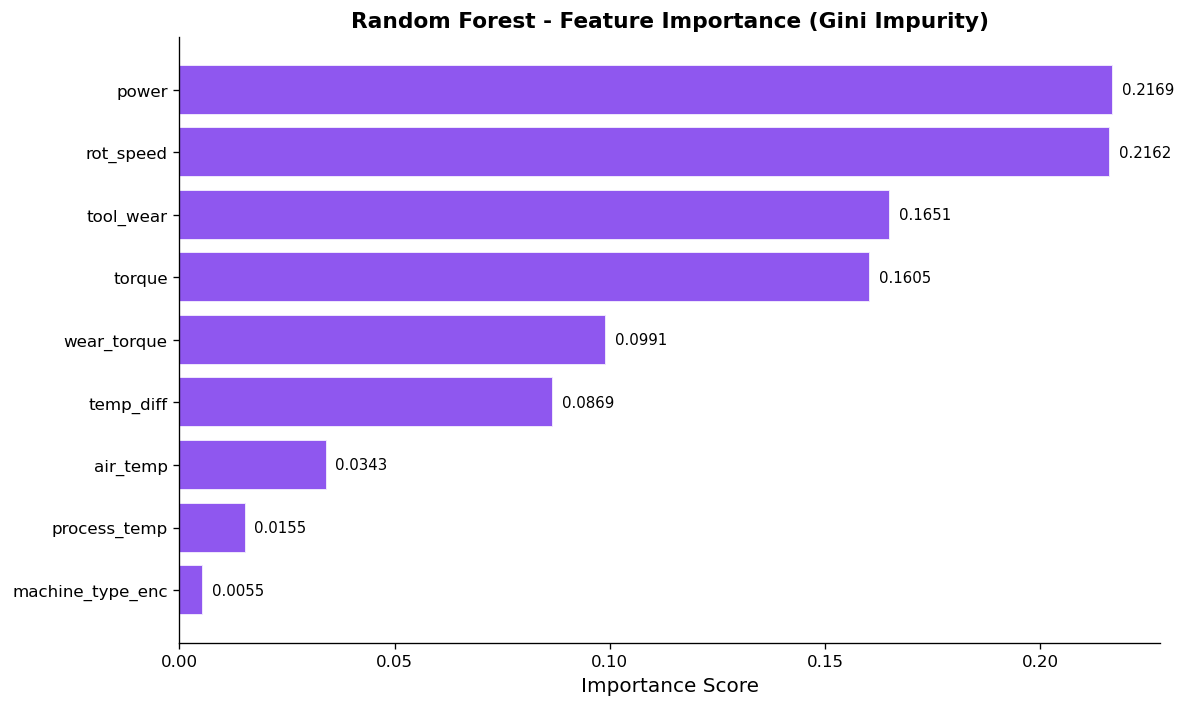


Top 3 Features:
power                : 0.2169
rot_speed            : 0.2162
tool_wear            : 0.1651


In [46]:
# Feature Importance (Built-in)
print('\nFeature Importance')
importances = pd.Series(rf_model.feature_importances_, index = FEATURE_COLS)
importances = importances.sort_values(ascending = True)

fig, ax = plt.subplots(figsize = (10, 6))
bars = ax.barh(importances.index, importances.values, color = PALETTE['rf'], 
               edgecolor = 'white', linewidth = 1.2, alpha = 0.85)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2, f"{val:.4f}", va = 'center', fontsize = 9)

ax.set_title('Random Forest - Feature Importance (Gini Impurity)', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Importance Score')
save_fig('4_rf_feature_importance.png')
plt.show()

top3 = importances.sort_values(ascending = False).head(3)
print(f"\nTop 3 Features:")
for feat, imp in top3.items():
    print(f"{feat:<20} : {imp:.4f}")


Learning Curve
Figure saved -> ../outputs/figures/4_rf_learning_curve.png


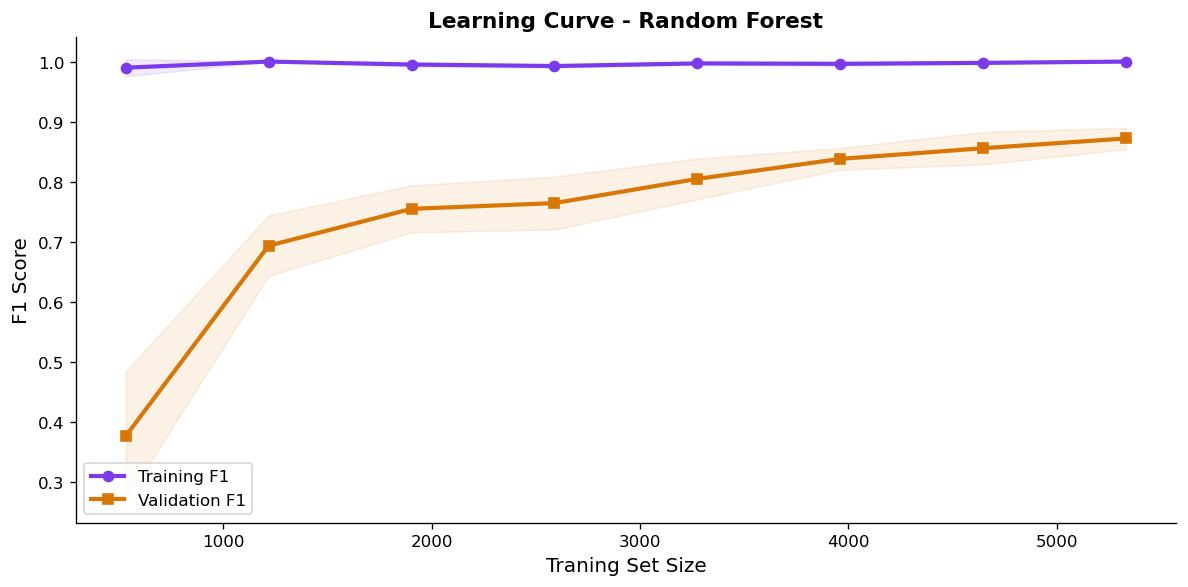

In [48]:
# Learning Curve
# Shows whether model benefits from more data or is overfitting
print('\nLearning Curve')

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(RandomForestClassifier(**rf_search.best_params_, class_weight = 'balanced',
                                                                              random_state = SEED, n_jobs = -1),
                                                       X_train, y_train, train_sizes = np.linspace(0.1, 1.0, 8),
                                                       cv = StratifiedKFold(n_splits = 3, shuffle = True, random_state = SEED),
                                                       scoring = 'f1', n_jobs = -1)

train_mean = train_scores.mean(axis = 1)
train_std = train_scores.std(axis = 1)
val_mean = val_scores.mean(axis = 1)
val_std = val_scores.std(axis = 1)

fig, ax = plt.subplots(figsize = (10, 5))
ax.plot(train_sizes, train_mean, 'o-', color = PALETTE['rf'], lw = 2.5, label = 'Training F1')
ax.plot(train_sizes, val_mean, 's-', color = PALETTE['warning'], lw = 2.5, label = 'Validation F1')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha = 0.1, color = PALETTE['rf'])
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha = 0.1, color = PALETTE['warning'])
ax.set_title('Learning Curve - Random Forest', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Traning Set Size')
ax.set_ylabel('F1 Score')
ax.legend()
save_fig('4_rf_learning_curve.png')
plt.show()

In [49]:
# Save Model & Results
print("\nSaving Model")

joblib.dump(rf_model, os.path.join(MODELS_DIR, "rf_model.pkl"))
print(f"Model saved → {MODELS_DIR}rf_model.pkl")

# Store metrics dict for Section 8 comparison dashboard
rf_results = {
    "model"      : "Random Forest",
    "color"      : PALETTE["rf"],
    "metrics"    : rf_metrics,
    "fpr"        : fpr_rf,
    "tpr"        : tpr_rf,
    "prec"       : prec_rf,
    "rec"        : rec_rf,
    "y_pred"     : y_pred_rf,
    "y_proba"    : y_proba_rf,
    "best_thresh": best_t,
    "cm"         : cm_rf,
}
print("rf_results dict stored for Section 8 comparison")


Saving Model
Model saved → ../outputs/models/rf_model.pkl
rf_results dict stored for Section 8 comparison


In [50]:
# Section Summary
section_banner("Section 4 — Summary")

print(f"{'Metric':<14}  {'Baseline':>10}  {'Tuned':>10}")
print(f"{'──────':<14}  {'────────':>10}  {'─────':>10}")
base_f1  = f1_score(y_test, y_pred_base)
base_auc = roc_auc_score(y_test, rf_base.predict_proba(X_test)[:,1])
print(f"{'F1-Score':<14}  {base_f1:>10.4f}  {rf_metrics['F1-Score']:>10.4f}")
print(f"{'ROC-AUC':<14}  {base_auc:>10.4f}  {rf_metrics['ROC-AUC']:>10.4f}")
print(f"{'Recall':<14}  {'—':>10}  {rf_metrics['Recall']:>10.4f}")
print()
print(f"Optimal decision threshold : {best_t:.2f}  (default: 0.50)")
print(f"Failures caught (TP)       : {tp}")
print(f"Failures missed (FN)       : {fn}  ← review in ROI section")
print()
print("Model saved  → outputs/models/rf_model.pkl")
print("rf_results   → available for Section 8 dashboard")
print()


  Section 4 — Summary

Metric            Baseline       Tuned
──────            ────────       ─────
F1-Score            0.8361      0.8480
ROC-AUC             0.9750      0.8887
Recall                   —      0.7794

Optimal decision threshold : 0.40  (default: 0.50)
Failures caught (TP)       : 53
Failures missed (FN)       : 15  ← review in ROI section

Model saved  → outputs/models/rf_model.pkl
rf_results   → available for Section 8 dashboard

